In [1]:
import os
import tempfile

import muon
import numpy as np
import requests
import scanpy as sc
import scvi
import seaborn as sns
import torch

/opt/conda/lib/python3.11/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.6.2 is installed, but it is not compatible with the installed jaxlib version 0.6.1, so it will not be used.
  warnings.warn(


In [2]:
torch.version.cuda

'12.6'

In [3]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.3.3


In [4]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

In [5]:
# # download preprocessed dataset
# mdata_path = os.path.join(save_dir.name, "pbmc_10k_preprocessed.h5mu")

# # Figshare direct download URL
# url = "https://figshare.com/ndownloader/files/54794234"

# # Download only if file doesn't already exist
# if not os.path.exists(mdata_path):
#     print(f"Downloading MuData file to {mdata_path}...")
#     r = requests.get(url)
#     with open(mdata_path, "wb") as f:
#         f.write(r.content)

# # Load the MuData object
# mdata = muon.read_h5mu(mdata_path)

/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [5]:
mdata = muon.read_h5mu("../../../oscb/uploads/scicar_cell_lines.h5mu")
mdata

/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 1151 × 92524
  var:	'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  uns:	'mofa', 'neighbors', 'umap', 'wnn'
  obsm:	'X_mofa', 'X_mofa_umap', 'X_umap', 'X_wnn_umap'
  varm:	'LFs'
  obsp:	'connectivities', 'distances', 'wnn_connectivities', 'wnn_distances'
  2 modalities
    rna:	1151 x 60550
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'size_factors', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
      var:	'gene_type', 'gene_short_name', 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'normalization_id', 'pca', 'umap', 'var_names_all'
      obsm:	'X_pca', 'X_svd', 'X_umap', 'mode2'
      varm:	'PCs'
      layers:	'LogCP10K', 'normalized', 'raw_counts'
      obsp:	'connectivities', 'distances'
    atac:	1151 x 31974
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'n_genes_by_counts', 'total_counts', 'leiden'
      var:	'id', 'chr', 'start', 'end', 'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'normalization_id', 'pca', 'umap'
      obsm:	'X_pca', 'X_svd', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'lognorm', 'normalized', 'raw_counts'
      obsp:	'connectivities', 'distances'

In [6]:
scvi.model.MULTIVI.setup_mudata(
    mdata,
    modalities={
        "rna_layer": "rna",
        "atac_layer": "atac",
    },
)

/opt/conda/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [7]:
model = scvi.model.MULTIVI(
    mdata,
    n_genes=len(mdata.mod["rna"].var),
    n_regions=len(mdata.mod["atac"].var),
)

model.view_anndata_setup()

/opt/conda/lib/python3.11/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Anndata setup with scvi-tools version 1.3.3.

Setup via `MULTIVI.setup_anndata` with arguments:

{
│   'rna_layer': None,
│   'atac_layer': None,
│   'protein_layer': None,
│   'batch_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None,
│   'idx_layer': None,
│   'modalities': {'rna_layer': 'rna', 'atac_layer': 'atac'}
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│          n_atac          │ 31974 │
│         n_batch          │   1   │
│         n_cells          │ 1151  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│      n_size_factor       │   0   │
│          n_vars          │ 60550 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │    adata.mod['rna'].X     │
│     atac     │    adata.mod['atac'].X    │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

In [12]:
type(mdata.mod["rna"].X) == np.ndarray

True

In [15]:
# For our sparse matrices, we want CSR rather than CSC as training will be faster
# We convert here since our downloaded dataset uses CSC (might not be the case for other datasets)
from scipy.sparse import csr_matrix

if type(mdata.mod["rna"].X) == np.ndarray:
    mdata.mod["rna"].X = csr_matrix(mdata.mod["rna"].X)
    mdata.mod["atac"].X = csr_matrix(mdata.mod["atac"].X)
    mdata.update()
else:
    mdata.mod["rna"].X = mdata.mod["rna"].X.tocsr()
    mdata.mod["atac"].X = mdata.mod["atac"].X.tocsr()
    mdata.update()

/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [16]:
model.train()

/opt/conda/lib/python3.11/site-packages/scvi/model/_multivi.py:340: UserWarning: Disabling adversarial classifier.
  training_plan = self._training_plan_cls(self.module, **plan_kwargs)
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_l

Training:   0%|          | 0/500 [00:00<?, ?it/s]

/opt/conda/lib/python3.11/site-packages/scvi/module/_multivae.py:874: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/opt/conda/lib/python3.11/site-packages/scvi/module/_multivae.py:874: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/opt/conda/lib/python3.11/site-packages/scvi/module/_multivae.py:874: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/opt/conda/lib/python3.11/site-packages/scvi/module/_multivae.py:874: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/opt/conda/lib/python3.11/site-packages/scvi/module/_multivae.py:874: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/opt/conda/lib/python3.11/site-packages/scvi/module/_multivae.py:874: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/opt/conda/lib/p

Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 4840.964. Signaling Trainer to stop.


In [17]:
model_dir = os.path.join(save_dir.name, "multivi")

model.save(model_dir, overwrite=True)

In [18]:
model = scvi.model.MULTIVI.load(model_dir, adata=mdata)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /tmp/tmp1u6juz_7/multivi/model.pt already downloaded                                                 


/opt/conda/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/opt/conda/lib/python3.11/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [19]:
mdata = model.adata

In [20]:
model = scvi.model.MULTIVI.load(model_dir, adata=mdata)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /tmp/tmp1u6juz_7/multivi/model.pt already downloaded                                                 


/opt/conda/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/opt/conda/lib/python3.11/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [21]:
mdata

MuData object with n_obs × n_vars = 1151 × 92524
  obs:	'_indices', '_scvi_batch', '_scvi_labels'
  var:	'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  uns:	'mofa', 'neighbors', 'umap', 'wnn', '_scvi_uuid', '_scvi_manager_uuid'
  obsm:	'X_mofa', 'X_mofa_umap', 'X_umap', 'X_wnn_umap'
  varm:	'LFs'
  obsp:	'connectivities', 'distances', 'wnn_connectivities', 'wnn_distances'
  2 modalities
    rna:	1151 x 60550
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'size_factors', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
      var:	'gene_type', 'gene_short_name', 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'normalization_id', 'pca', 'umap', 'var_names_all'
      obsm:	'X_pca', 'X_svd', 'X_umap', 'mode2'
      varm:	'PCs'
      layers:	'LogCP10K', 'normalized', 'raw_counts'
      obsp:	'connectivities', 'distances'
    atac:	1151 x 31974
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'n_genes_by_counts', 'total_counts', 'leiden'
      var:	'id', 'chr', 'start', 'end', 'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'normalization_id', 'pca', 'umap'
      obsm:	'X_pca', 'X_svd', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'lognorm', 'normalized', 'raw_counts'
      obsp:	'connectivities', 'distances'

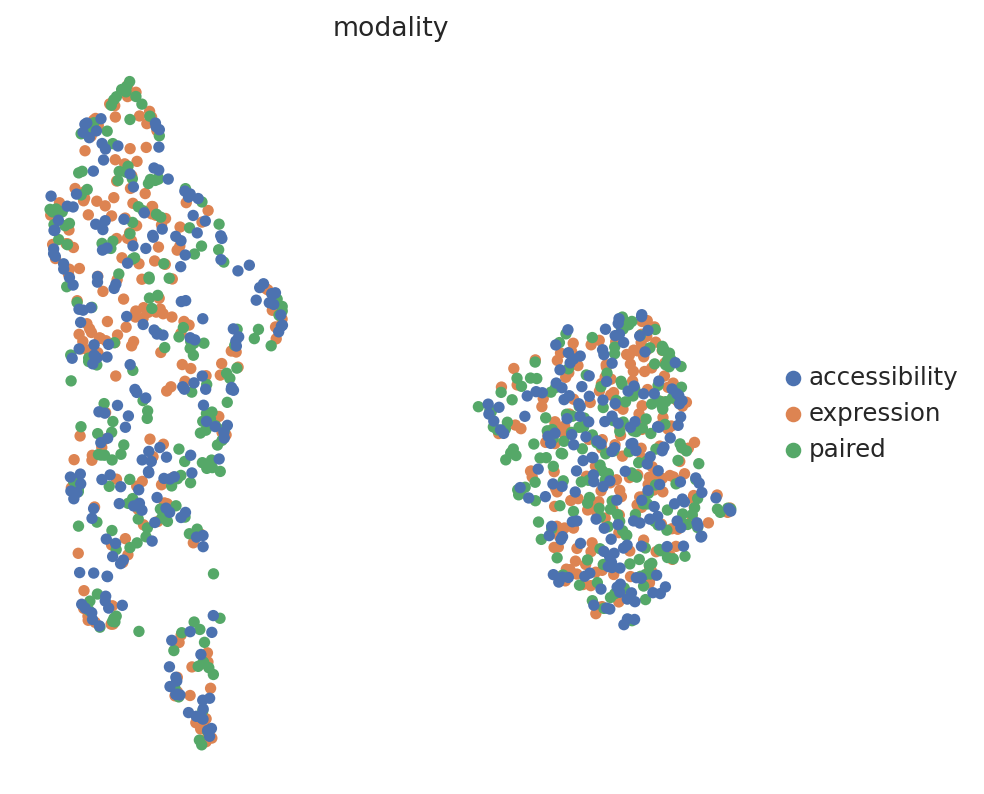

In [22]:
# Below we an cell annotations for modality, so we can color the UMAP

MULTIVI_LATENT_KEY = "X_multivi"

mdata.obsm[MULTIVI_LATENT_KEY] = model.get_latent_representation()
sc.pp.neighbors(mdata, use_rep=MULTIVI_LATENT_KEY)
sc.tl.umap(mdata, min_dist=0.2)

n = mdata.n_obs // 3

# initialize the column first
mdata.obs["modality"] = ""

# set modality of first third to rna
mdata.obs.iloc[:n, mdata.obs.columns.get_loc("modality")] = "expression"

# set modality of second third to both
mdata.obs.iloc[n : 2 * n, mdata.obs.columns.get_loc("modality")] = "paired"

# set modality of last third to atac
mdata.obs.iloc[2 * n :, mdata.obs.columns.get_loc("modality")] = "accessibility"

sc.pl.umap(mdata, color="modality")

In [34]:
mdata.obs

,rna:cell_name,rna:experiment,rna:treatment_time,rna:source,rna:group,rna:cell_type,rna:size_factors,rna:n_genes_by_counts,rna:total_counts,rna:total_counts_mt,...,atac:cell_type,atac:n_genes_by_counts,atac:total_counts,atac:leiden,rna:mod_weight,atac:mod_weight,_indices,_scvi_batch,_scvi_labels,modality
sci-RNA-A-001.CGTATTGAGA,A549,co_assay,3.0,Human,A549_3h,A549,1259.0,765,1259.0,0.0,...,A549,599,1473.0,0,0.935841,0.064159,0,0,0,expression
sci-RNA-A-001.GACCAATGCG,A549,co_assay,0.0,Human,A549_0h,A549,926.0,606,926.0,0.0,...,A549,444,1069.0,0,0.999993,0.000007,1,0,0,expression
sci-RNA-A-002.ACGCGTATCG,293T,co_assay,NaN,Human,293T_3T3,293T,6637.0,2865,6637.0,0.0,...,293T,528,1180.0,2,0.999994,0.000006,2,0,0,expression
sci-RNA-A-003.TCTCTCATCC,A549,co_assay,0.0,Human,A549_0h,A549,14328.0,4538,14328.0,0.0,...,A549,1006,2372.0,0,0.998152,0.001848,3,0,0,expression
sci-RNA-A-003.TTCTCTACTA,A549,co_assay,1.0,Human,A549_1h,A549,1571.0,900,1571.0,0.0,...,A549,1323,3081.0,1,0.842837,0.157163,4,0,0,expression
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sci-RNA-E-094.TCTAGTCAAG,A549,co_assay,1.0,Human,A549_1h,A549,2999.0,1503,2999.0,0.0,...,A549,735,1684.0,0,0.771010,0.228990,1146,0,0,accessibility
sci-RNA-E-095.CTGAAGAGAC,A549,co_assay,1.0,Human,A549_1h,A549,1322.0,780,1322.0,0.0,...,A549,697,1423.0,0,0.999873,0.000127,1147,0,0,accessibility
sci-RNA-E-096.AATCGAACTC,A549,co_assay,1.0,Human,A549_1h,A549,2702.0,1480,2702.0,0.0,...,A549,1819,4036.0,1,0.841273,0.158727,1148,0,0,accessibility
sci-RNA-E-096.CGAATCTCCT,A549,co_assay,3.0,Human,A549_3h,A549,3099.0,1532,3099.0,0.0,...,A549,562,1211.0,0,0.985198,0.014802,1149,0,0,accessibility


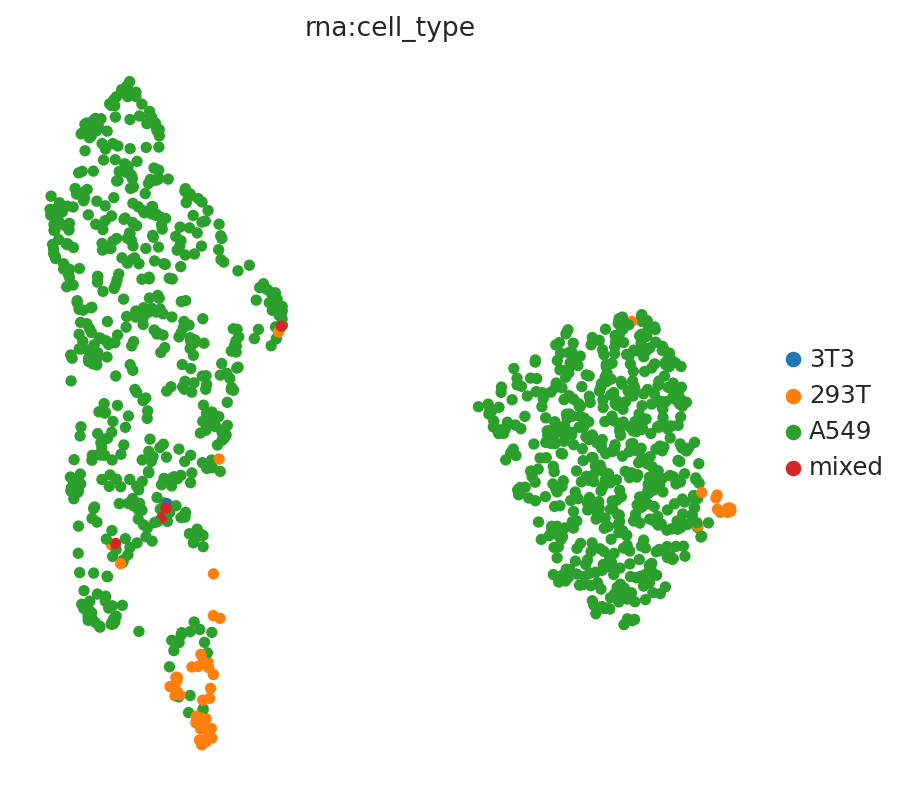

In [35]:
sc.pl.umap(mdata, color="rna:cell_type")

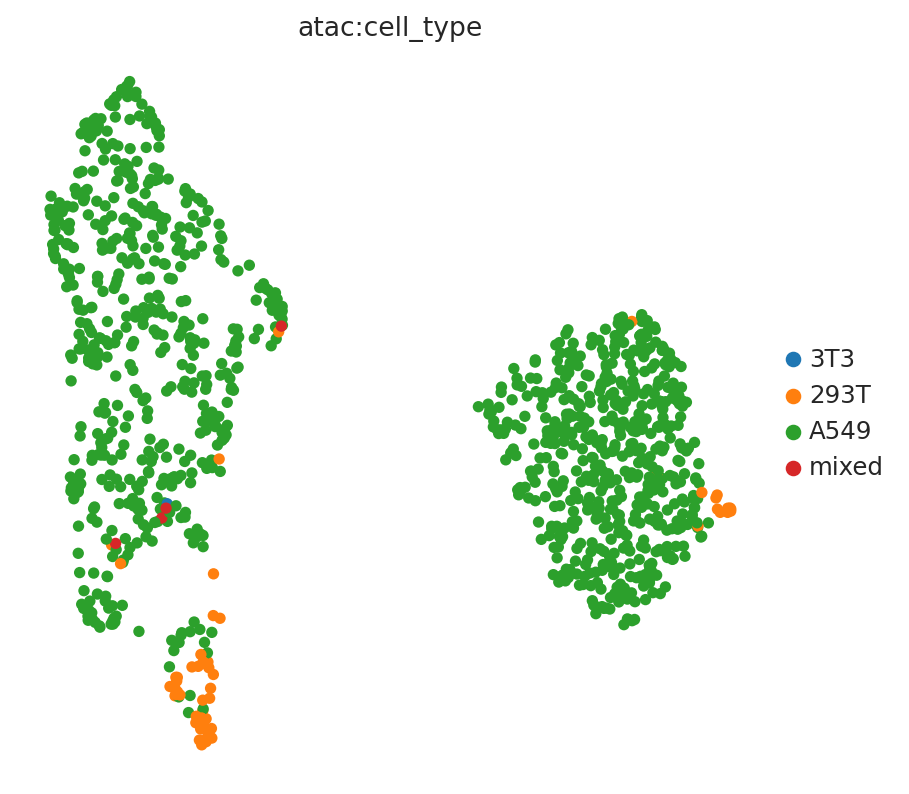

In [36]:
sc.pl.umap(mdata, color="atac:cell_type")

In [37]:
mdata

MuData object with n_obs × n_vars = 1151 × 92524
  obs:	'_indices', '_scvi_batch', '_scvi_labels', 'modality'
  var:	'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  uns:	'mofa', 'neighbors', 'umap', 'wnn', '_scvi_uuid', '_scvi_manager_uuid', 'modality_colors'
  obsm:	'X_mofa', 'X_mofa_umap', 'X_umap', 'X_wnn_umap', 'X_multivi'
  varm:	'LFs'
  obsp:	'connectivities', 'distances', 'wnn_connectivities', 'wnn_distances'
  2 modalities
    rna:	1151 x 60550
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'size_factors', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
      var:	'gene_type', 'gene_short_name', 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'normalization_id', 'pca', 'umap', 'var_names_all'
      obsm:	'X_pca', 'X_svd', 'X_umap', 'mode2'
      varm:	'PCs'
      layers:	'LogCP10K', 'normalized', 'raw_counts'
      obsp:	'connectivities', 'distances'
    atac:	1151 x 31974
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'n_genes_by_counts', 'total_counts', 'leiden'
      var:	'id', 'chr', 'start', 'end', 'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'normalization_id', 'pca', 'umap'
      obsm:	'X_pca', 'X_svd', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'lognorm', 'normalized', 'raw_counts'
      obsp:	'connectivities', 'distances'

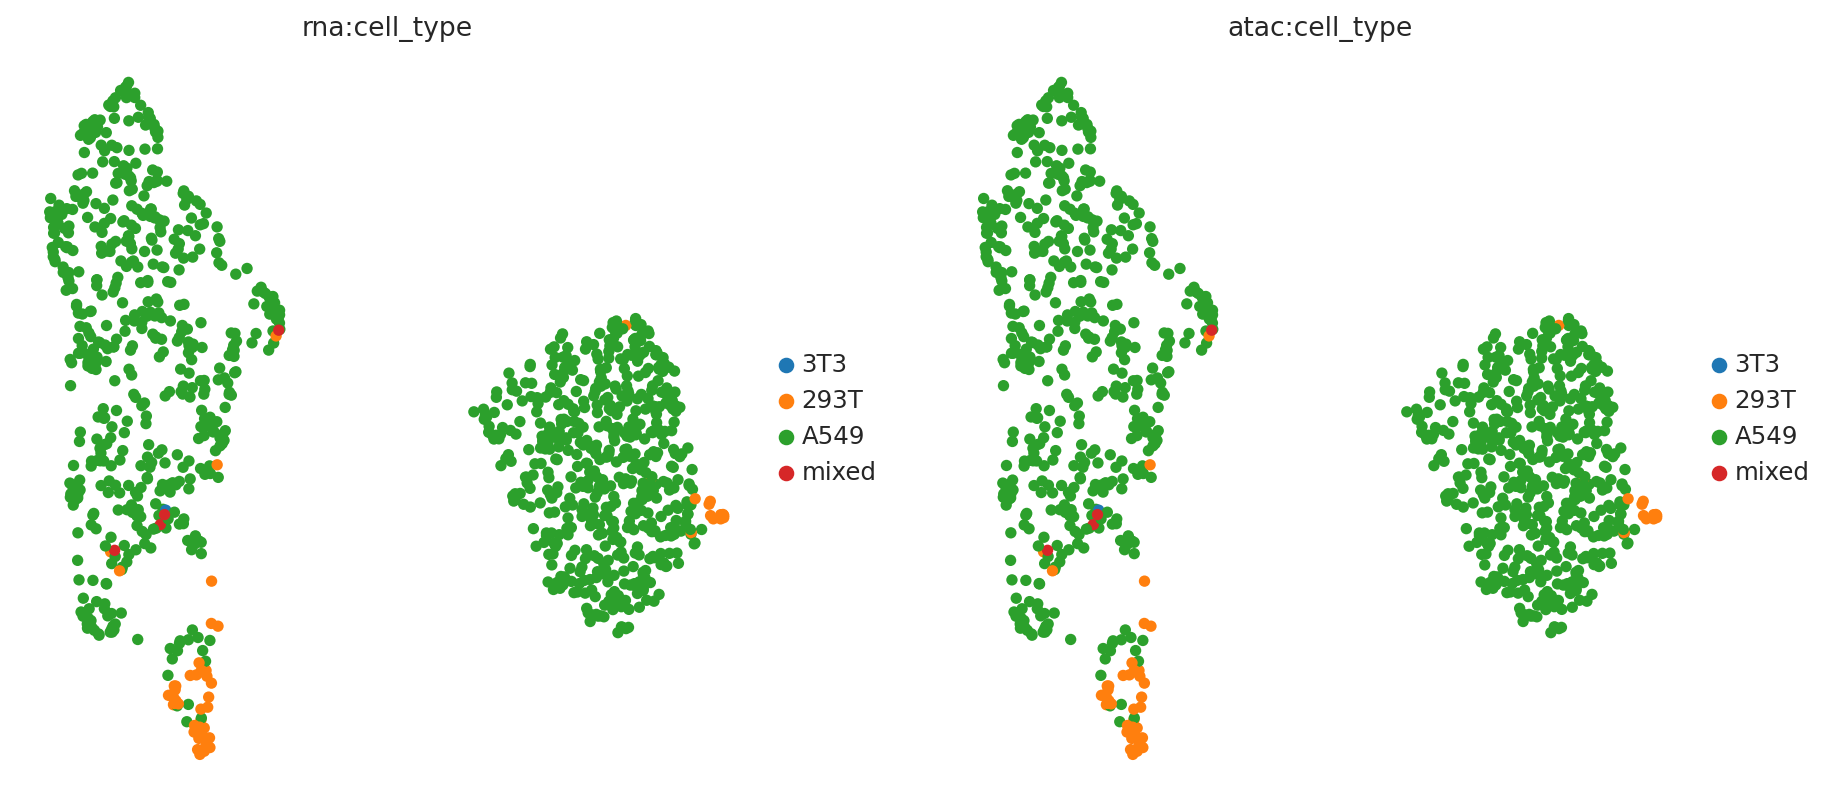

In [40]:
import muon as mu

mu.pl.embedding(mdata, basis="X_umap", color=["rna:cell_type", "atac:cell_type"])

# Impute missing modalities

In [23]:
imputed_expression = model.get_normalized_expression()

In [25]:
mdata.mod["rna"].var.index

Index(['ENSG00000227232.4', 'ENSG00000238009.2', 'ENSG00000237683.5',
       'ENSG00000268903.1', 'ENSG00000241860.2', 'ENSG00000228463.4',
       'ENSG00000237094.7', 'ENSG00000269732.1', 'ENSG00000235146.2',
       'ENSG00000230021.3',
       ...
       'ENSMUSG00000064356.3', 'ENSMUSG00000064363.1', 'ENSMUSG00000064365.1',
       'ENSMUSG00000064366.1', 'ENSMUSG00000064367.1', 'ENSMUSG00000064368.1',
       'ENSMUSG00000064369.1', 'ENSMUSG00000064370.1', 'ENSMUSG00000064371.1',
       'ENSMUSG00000064372.1'],
      dtype='object', name='gene_id', length=60550)

In [27]:
np.where(mdata.mod["rna"].var.index == "ENSMUSG00000064363.1")

(array([60541]),)

In [28]:
mdata

MuData object with n_obs × n_vars = 1151 × 92524
  obs:	'_indices', '_scvi_batch', '_scvi_labels', 'modality'
  var:	'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  uns:	'mofa', 'neighbors', 'umap', 'wnn', '_scvi_uuid', '_scvi_manager_uuid', 'modality_colors'
  obsm:	'X_mofa', 'X_mofa_umap', 'X_umap', 'X_wnn_umap', 'X_multivi'
  varm:	'LFs'
  obsp:	'connectivities', 'distances', 'wnn_connectivities', 'wnn_distances'
  2 modalities
    rna:	1151 x 60550
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'size_factors', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
      var:	'gene_type', 'gene_short_name', 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'normalization_id', 'pca', 'umap', 'var_names_all'
      obsm:	'X_pca', 'X_svd', 'X_umap', 'mode2'
      varm:	'PCs'
      layers:	'LogCP10K', 'normalized', 'raw_counts'
      obsp:	'connectivities', 'distances'
    atac:	1151 x 31974
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'n_genes_by_counts', 'total_counts', 'leiden'
      var:	'id', 'chr', 'start', 'end', 'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'normalization_id', 'pca', 'umap'
      obsm:	'X_pca', 'X_svd', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'lognorm', 'normalized', 'raw_counts'
      obsp:	'connectivities', 'distances'

In [30]:
mdata.obsm['X_multivi'].shape

(1151, 11)

In [31]:
mdata.obs

,rna:cell_name,rna:experiment,rna:treatment_time,rna:source,rna:group,rna:cell_type,rna:size_factors,rna:n_genes_by_counts,rna:total_counts,rna:total_counts_mt,...,atac:cell_type,atac:n_genes_by_counts,atac:total_counts,atac:leiden,rna:mod_weight,atac:mod_weight,_indices,_scvi_batch,_scvi_labels,modality
sci-RNA-A-001.CGTATTGAGA,A549,co_assay,3.0,Human,A549_3h,A549,1259.0,765,1259.0,0.0,...,A549,599,1473.0,0,0.935841,0.064159,0,0,0,expression
sci-RNA-A-001.GACCAATGCG,A549,co_assay,0.0,Human,A549_0h,A549,926.0,606,926.0,0.0,...,A549,444,1069.0,0,0.999993,0.000007,1,0,0,expression
sci-RNA-A-002.ACGCGTATCG,293T,co_assay,NaN,Human,293T_3T3,293T,6637.0,2865,6637.0,0.0,...,293T,528,1180.0,2,0.999994,0.000006,2,0,0,expression
sci-RNA-A-003.TCTCTCATCC,A549,co_assay,0.0,Human,A549_0h,A549,14328.0,4538,14328.0,0.0,...,A549,1006,2372.0,0,0.998152,0.001848,3,0,0,expression
sci-RNA-A-003.TTCTCTACTA,A549,co_assay,1.0,Human,A549_1h,A549,1571.0,900,1571.0,0.0,...,A549,1323,3081.0,1,0.842837,0.157163,4,0,0,expression
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sci-RNA-E-094.TCTAGTCAAG,A549,co_assay,1.0,Human,A549_1h,A549,2999.0,1503,2999.0,0.0,...,A549,735,1684.0,0,0.771010,0.228990,1146,0,0,accessibility
sci-RNA-E-095.CTGAAGAGAC,A549,co_assay,1.0,Human,A549_1h,A549,1322.0,780,1322.0,0.0,...,A549,697,1423.0,0,0.999873,0.000127,1147,0,0,accessibility
sci-RNA-E-096.AATCGAACTC,A549,co_assay,1.0,Human,A549_1h,A549,2702.0,1480,2702.0,0.0,...,A549,1819,4036.0,1,0.841273,0.158727,1148,0,0,accessibility
sci-RNA-E-096.CGAATCTCCT,A549,co_assay,3.0,Human,A549_3h,A549,3099.0,1532,3099.0,0.0,...,A549,562,1211.0,0,0.985198,0.014802,1149,0,0,accessibility


In [32]:
mdata[mdata.obs["modality"]=="paired"].obsm['X_multivi'].shape

(383, 11)

In [ ]:
mdata[mdata.obs["modality"]=="paired"].obsm['X_multivi'].shape

In [ ]:
scvi.model.MULTIVI.setup_anndata

In [ ]:
model = scvi.model.MULTIVI(
    mdata,
    n_genes=len(mdata.mod["rna_subset"].var),
    n_regions=len(mdata.mod["atac_subset"].var),
)

model.view_anndata_setup()

In [ ]:
model = scvi.model.MULTIVI(
    mdata,
    n_genes=len(mdata.mod["rna_subset"].var),
    n_regions=len(mdata.mod["atac_subset"].var),
)

model.view_anndata_setup()

In [ ]:
model.train()

In [ ]:
model_dir = os.path.join(save_dir.name, "multivi_pbmc10k")

model.save(model_dir, overwrite=True)

In [ ]:
model = scvi.model.MULTIVI.load(model_dir, adata=mdata)

In [ ]:
mdata = model.adata

In [ ]:
model = scvi.model.MULTIVI.load(model_dir, adata=mdata)

In [ ]:
# Below we an cell annotations for modality, so we can color the UMAP

MULTIVI_LATENT_KEY = "X_multivi"

mdata.obsm[MULTIVI_LATENT_KEY] = model.get_latent_representation()
sc.pp.neighbors(mdata, use_rep=MULTIVI_LATENT_KEY)
sc.tl.umap(mdata, min_dist=0.2)

n = mdata.n_obs // 3

# initialize the column first
mdata.obs["modality"] = ""

# set modality of first third to rna
mdata.obs.iloc[:n, mdata.obs.columns.get_loc("modality")] = "expression"

# set modality of second third to both
mdata.obs.iloc[n : 2 * n, mdata.obs.columns.get_loc("modality")] = "paired"

# set modality of last third to atac
mdata.obs.iloc[2 * n :, mdata.obs.columns.get_loc("modality")] = "accessibility"

sc.pl.umap(mdata, color="modality")

In [ ]:
imputed_expression = model.get_normalized_expression()

In [ ]:
mdata.mod["rna_subset"].var.index

In [41]:
mdata.X

In [45]:
mdata.write("../../../oscb/uploads/scicar_cell_lines.h5mu")

/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


# Evaluation

In [46]:
from sklearn.metrics import adjusted_rand_score as ari
ari(mdata.obs['rna:cell_type'], mdata.obs['atac:cell_type'])

1.0

In [47]:
import scipy.io
import scib

In [49]:
scib_anndata = sc.AnnData(mdata.obsm["X_mofa"]).copy()
scib_anndata.obs = mdata.obs.copy()
scib_anndata.obsp["connectivities"] = mdata.obsp["connectivities"].copy()
scib_anndata.obsm["X_mofa"] = mdata.obsm["X_mofa"].copy()

metrics_mofa = scib.metrics.metrics(
    scib_anndata,
    scib_anndata,
    batch_key="rna:group",
    label_key="rna:cell_type",
    embed="X_mofa",
    ari_=True,
    nmi_=True,
    silhouette_=True,
    graph_conn_=True,
    isolated_labels_asw_=True,
)
metrics_mofa

Recompute neighbors on rep X_mofa instead of None
Cluster for cluster_0.2 with leiden


/opt/conda/lib/python3.11/site-packages/scib/metrics/clustering.py:96: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)


Cluster for cluster_0.4 with leiden
Cluster for cluster_0.6 with leiden
Cluster for cluster_0.8 with leiden
Cluster for cluster_1.0 with leiden
Cluster for cluster_1.2 with leiden
Cluster for cluster_1.4 with leiden
Cluster for cluster_1.6 with leiden
Cluster for cluster_1.8 with leiden
Cluster for cluster_2.0 with leiden
NMI...
ARI...
Silhouette score...
Isolated labels ASW...
Graph connectivity...


/opt/conda/lib/python3.11/site-packages/scib/metrics/isolated_labels.py:311: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_per_lab = tmp.groupby(label_key).agg({batch_key: "count"})
/opt/conda/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/opt/conda/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/opt/conda/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and 

,0
NMI_cluster/label,0.206737
ARI_cluster/label,0.046278
ASW_label,0.904672
ASW_label/batch,0.947134
PCR_batch,NaN
cell_cycle_conservation,NaN
isolated_label_F1,NaN
isolated_label_silhouette,0.463697
graph_conn,0.812500
kBET,NaN


In [50]:
scib_anndata = sc.AnnData(mdata.obsm["X_multivi"]).copy()
scib_anndata.obs = mdata.obs.copy()
scib_anndata.obsp["connectivities"] = mdata.obsp["connectivities"].copy()
scib_anndata.obsm["X_multivi"] = mdata.obsm["X_multivi"].copy()

metrics_multivi = scib.metrics.metrics(
    scib_anndata,
    scib_anndata,
    batch_key="rna:group",
    label_key="rna:cell_type",
    embed="X_multivi",
    ari_=True,
    nmi_=True,
    silhouette_=True,
    graph_conn_=True,
    isolated_labels_asw_=True,
)
metrics_multivi

Recompute neighbors on rep X_multivi instead of None
Cluster for cluster_0.2 with leiden
Cluster for cluster_0.4 with leiden
Cluster for cluster_0.6 with leiden
Cluster for cluster_0.8 with leiden
Cluster for cluster_1.0 with leiden
Cluster for cluster_1.2 with leiden
Cluster for cluster_1.4 with leiden
Cluster for cluster_1.6 with leiden
Cluster for cluster_1.8 with leiden
Cluster for cluster_2.0 with leiden
NMI...
ARI...
Silhouette score...
Isolated labels ASW...
Graph connectivity...


/opt/conda/lib/python3.11/site-packages/scib/metrics/isolated_labels.py:311: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_per_lab = tmp.groupby(label_key).agg({batch_key: "count"})
/opt/conda/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/opt/conda/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/opt/conda/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and 

,0
NMI_cluster/label,0.181115
ARI_cluster/label,0.085388
ASW_label,0.631138
ASW_label/batch,0.936868
PCR_batch,NaN
cell_cycle_conservation,NaN
isolated_label_F1,NaN
isolated_label_silhouette,0.461465
graph_conn,0.933468
kBET,NaN


In [51]:
scib_anndata = sc.AnnData(mdata.obsm["X_wnn_umap"]).copy()
scib_anndata.obs = mdata.obs.copy()
scib_anndata.obsp["connectivities"] = mdata.obsp["connectivities"].copy()
scib_anndata.obsm["X_wnn_umap"] = mdata.obsm["X_wnn_umap"].copy()

metrics_wnn = scib.metrics.metrics(
    scib_anndata,
    scib_anndata,
    batch_key="rna:group",
    label_key="rna:cell_type",
    embed="X_wnn_umap",
    ari_=True,
    nmi_=True,
    silhouette_=True,
    graph_conn_=True,
    isolated_labels_asw_=True,
)
metrics_wnn

Recompute neighbors on rep X_wnn_umap instead of None
Cluster for cluster_0.2 with leiden
Cluster for cluster_0.4 with leiden
Cluster for cluster_0.6 with leiden
Cluster for cluster_0.8 with leiden
Cluster for cluster_1.0 with leiden
Cluster for cluster_1.2 with leiden
Cluster for cluster_1.4 with leiden
Cluster for cluster_1.6 with leiden
Cluster for cluster_1.8 with leiden
Cluster for cluster_2.0 with leiden
NMI...
ARI...
Silhouette score...
Isolated labels ASW...
Graph connectivity...


/opt/conda/lib/python3.11/site-packages/scib/metrics/isolated_labels.py:311: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_per_lab = tmp.groupby(label_key).agg({batch_key: "count"})
/opt/conda/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/opt/conda/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/opt/conda/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and 

,0
NMI_cluster/label,0.204752
ARI_cluster/label,0.044467
ASW_label,0.819512
ASW_label/batch,0.919507
PCR_batch,NaN
cell_cycle_conservation,NaN
isolated_label_F1,NaN
isolated_label_silhouette,0.379934
graph_conn,0.933468
kBET,NaN


In [52]:
mdata

MuData object with n_obs × n_vars = 1151 × 92524
  obs:	'_indices', '_scvi_batch', '_scvi_labels', 'modality'
  var:	'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  uns:	'mofa', 'neighbors', 'umap', 'wnn', '_scvi_uuid', '_scvi_manager_uuid', 'modality_colors'
  obsm:	'X_mofa', 'X_mofa_umap', 'X_umap', 'X_wnn_umap', 'X_multivi'
  varm:	'LFs'
  obsp:	'connectivities', 'distances', 'wnn_connectivities', 'wnn_distances'
  2 modalities
    rna:	1151 x 60550
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'size_factors', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
      var:	'gene_type', 'gene_short_name', 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'normalization_id', 'pca', 'umap', 'var_names_all'
      obsm:	'X_pca', 'X_svd', 'X_umap', 'mode2'
      varm:	'PCs'
      layers:	'LogCP10K', 'normalized', 'raw_counts'
      obsp:	'connectivities', 'distances'
    atac:	1151 x 31974
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'n_genes_by_counts', 'total_counts', 'leiden'
      var:	'id', 'chr', 'start', 'end', 'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'normalization_id', 'pca', 'umap'
      obsm:	'X_pca', 'X_svd', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'lognorm', 'normalized', 'raw_counts'
      obsp:	'connectivities', 'distances'

In [60]:
list(mdata.mod.keys())

['rna', 'atac']

In [65]:
0==0.0

True

In [68]:
y = {[0.9, 0,0, 0.8, 0.7]}

for key, value in y.items():
    print(key)
    print(value)

TypeError: unhashable type: 'list'